# val_03 — Can pose tracking find licks the lickometer missed?

[dynamic-foraging-processing#96](https://github.com/AllenNeuralDynamics/dynamic-foraging-processing/issues/96):
the mouse licks, the video shows it, the lickometer does not register it. QC is wanted for those
cases.

A bottom-view camera tracks the tongue with Lightning Pose. A lick is called from the pose data
when the tongue tip comes within a fixed pixel distance of a spout. Against the lickometer:

| category | meaning |
|---|---|
| matched | tongue reached the spout, lickometer registered contact |
| pose-only | tongue reached the spout, no lickometer contact — the candidate missed lick |
| lickometer-only | lickometer registered contact, no tongue detected at the spout |

A pose-only event is either a lick the lickometer missed or a pose error: the tongue approaching
without contacting, model inaccuracy, or another part of the tongue touching the spout. Event
timing alone does not separate them.

**Contents**
1. Setup
2. The example session
3. What the pose data looks like
4. Tongue-to-spout distance at lickometer licks
5. Threshold sweep
6. Individual pose-only events
7. Miss rate per session
8. Possible QC metrics
9. Limitations

The session in #96 (`behavior_856239_2026-07-24_12-50-23`) has no pose output currently. The
processed set covers 53 sessions / 17 subjects, 2024-05-31 to 2025-07-03. §3-§6 use one session;
§7 uses all of them.

Code Ocean only — needs the per-session `intermediate_data/` parquets. Locally each data cell
prints a skip line.

## 1. Setup

In [23]:
%matplotlib inline
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_kinematics_utils import (
    filter_timestamps_refractory,
    mask_keypoint_data,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_lickometer_utils import (
    detect_licks,
    calculate_metrics_witheventkeys,
)
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import find_session_dir
from aind_dynamic_foraging_behavior_video_analysis.video_alignment import (
    session_time_to_video_time,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.video_clip_utils import (
    extract_clips_ffmpeg_encode,
    get_video_time,
    find_labeled_video,
)

from plotstyle import apply_style, PALETTE, style_ax, save_fig
apply_style()

In [24]:
if Path("/root/capsule").exists():
    ENV     = "codeocean"
    SCRATCH = Path("/root/capsule/scratch")
    DATA    = Path("/root/capsule/data")
else:
    ENV     = "local"
    SCRATCH = Path("/Users/mib/Documents/Code/kinematics_analysis/data/for_local").parent
    DATA    = SCRATCH

IS_CO    = ENV == "codeocean"
FIG_DIR  = SCRATCH / "figures" / "val_03_missed_licks"
SAVE_FIG = False

SESSION_DIR     = SCRATCH / "session_analysis_mlk"
EXAMPLE_SESSION = "behavior_716325_2024-05-31_10-31-14"

# Detection parameters. PIXEL_THRESHOLD and T_REFRACTORY are val_02's chosen operating
# point; MATCH_WINDOW is the coincidence window for calling two events the same lick.
CONF            = 0.8    # keypoint confidence floor for masking
PIXEL_THRESHOLD = 30     # tongue-to-spout distance that counts as a lick, in pixels
T_REFRACTORY    = 0.1    # s; suppresses re-detection from jitter around the threshold
MATCH_WINDOW    = 0.1    # s; pose and lickometer events this close are the same lick

# Colors, fixed across every figure below.
C_MATCH = PALETTE["baseline"]   # matched: pose and lickometer agree
C_POSE  = PALETTE["pos"]        # pose-only: candidate missed lick
C_LICKO = PALETTE["neg"]        # lickometer-only

print("ENV={}".format(ENV))

ENV=codeocean


## 2. The example session

Session `behavior_716325_2024-05-31_10-31-14`

In [25]:
def load_session(inter):
    """Load one session's tongue keypoints, spout positions and lickometer licks.

    Parameters
    ----------
    inter : pathlib.Path
        The session's ``intermediate_data`` directory.

    Returns
    -------
    dict
        ``tongue`` (masked keypoint table on session time), ``spoutL``/``spoutR`` (mean
        positions, already de-mirrored), ``licks`` (lickometer times, session time) and
        ``video_offset`` (seconds to add to session time to get video time, via
        :func:`video_clip_utils.get_video_time`).
    """
    keypoint_dfs = {
        key: pd.read_parquet(inter / "kps_raw_{}.parquet".format(key))
        for key in ["tongue_tip_center", "spout_l", "spout_r"]
    }
    kins = pd.read_parquet(inter / "tongue_kins.parquet",
                           columns=["time", "time_in_session"])

    tongue = mask_keypoint_data(keypoint_dfs, "tongue_tip_center", confidence_threshold=CONF)
    # kps_raw_* `time` is video-relative. get_video_time reads the session->video offset off
    # the first row of tongue_kins, which carries both bases; calling it at 0 returns the
    # offset itself.
    video_offset = float(get_video_time(0.0, kins))
    tongue["time"] = kins["time_in_session"].values

    return {
        # NB the bottom camera mirrors left/right, so spout_r holds the left spout.
        "spoutL": np.mean(keypoint_dfs["spout_r"][["x", "y"]], 0),
        "spoutR": np.mean(keypoint_dfs["spout_l"][["x", "y"]], 0),
        "tongue": tongue,
        "licks": np.sort(
            pd.read_parquet(inter / "nwb_df_licks.parquet")["timestamps"].to_numpy()),
        "video_offset": video_offset,
    }


def add_spout_distance(tongue, spoutL, spoutR):
    """Add per-frame distance to the nearer spout. Untracked frames stay NaN."""
    tongue = tongue.copy()
    tracked = tongue[["x", "y"]].notna().all(axis=1)
    xy = tongue.loc[tracked, ["x", "y"]].to_numpy()
    dL = np.linalg.norm(xy - np.array([spoutL["x"], spoutL["y"]]), axis=1)
    dR = np.linalg.norm(xy - np.array([spoutR["x"], spoutR["y"]]), axis=1)
    tongue["spout_distance"] = np.nan
    tongue.loc[tracked, "spout_distance"] = np.minimum(dL, dR)
    return tongue

In [26]:
if not IS_CO:
    print("[skip] Code Ocean only: needs session_analysis_mlk/<session>/intermediate_data/.")
else:
    inter = find_session_dir(EXAMPLE_SESSION, roots=[SESSION_DIR]) / "intermediate_data"
    S = load_session(inter)
    S["tongue"] = add_spout_distance(S["tongue"], S["spoutL"], S["spoutR"])

    tongue = S["tongue"]
    all_licks = S["licks"]
    VIDEO_OFFSET = S["video_offset"]

    tracked = tongue["x"].notna()
    duration = float(tongue["time"].max() - tongue["time"].min())

    print("Session:          {}".format(EXAMPLE_SESSION))
    print("Frames:           {:,} over {:.0f} s".format(len(tongue), duration))
    print("Tracked at conf >= {}: {:,} ({:.0%})".format(CONF, int(tracked.sum()),
                                                        tracked.mean()))
    print("Lickometer licks: {:,}  ({:.2f} / s)".format(len(all_licks),
                                                        len(all_licks) / duration))
    print("Video offset:     {:.3f} s  (session time + this = video time)".format(VIDEO_OFFSET))

Session:          behavior_716325_2024-05-31_10-31-14
Frames:           2,689,718 over 5379 s
Tracked at conf >= 0.8: 334,418 (12%)
Lickometer licks: 5,846  (1.09 / s)
Video offset:     48.578 s  (session time + this = video time)


## 3. What the pose data looks like

An 8 s window of ordinary licking.

Top: tongue tip position, both spout positions marked.

Bottom: distance to the nearer spout. Gaps are frames below confidence 0.8, where the tongue is
inside the mouth. Dashed line is the 30 px threshold; ticks are lickometer licks.

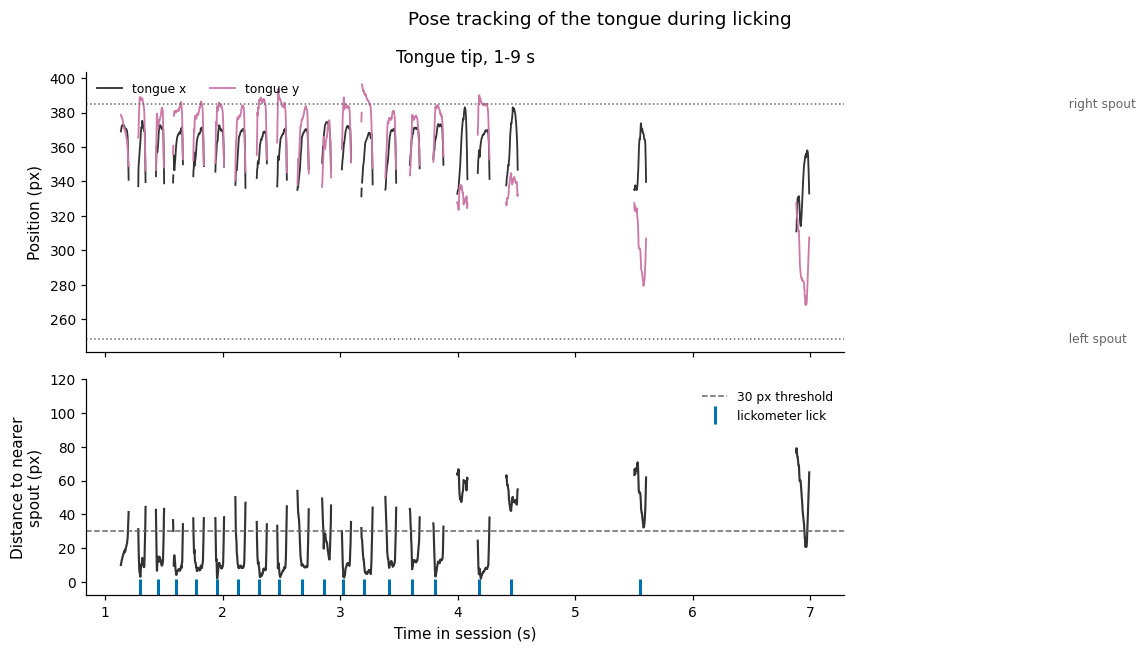

Window: 1.1-9.1 s | frames 4,000 | tracked 23% | lickometer licks 18


In [27]:
if not IS_CO:
    print("[skip] Figure 1 needs the example session.")
else:
    # An 8 s window starting at the 20th lickometer lick, so it lands in real licking.
    w0 = float(all_licks[20]) - 1.0
    w1 = w0 + 8.0
    win = tongue[(tongue["time"] >= w0) & (tongue["time"] <= w1)]
    win_licks = all_licks[(all_licks >= w0) & (all_licks <= w1)]

    fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True, layout="constrained",
                            gridspec_kw={"height_ratios": [1.3, 1]})

    # -- top: tongue x and y, with spout positions --
    axs[0].plot(win["time"], win["x"], lw=1.2, color=PALETTE["all"], label="tongue x")
    axs[0].plot(win["time"], win["y"], lw=1.2, color=PALETTE["accent"], label="tongue y")
    for spout, name in [(S["spoutL"], "left spout"), (S["spoutR"], "right spout")]:
        axs[0].axhline(spout["y"], color=PALETTE["neutral"], ls=":", lw=1)
        axs[0].text(w1, spout["y"], "  " + name, va="center", fontsize=8,
                    color=PALETTE["neutral"])
    axs[0].set_ylabel("Position (px)")
    axs[0].legend(loc="upper left", fontsize=8, ncol=2)
    axs[0].set_title("Tongue tip, {:.0f}-{:.0f} s".format(w0, w1))

    # -- bottom: distance to nearer spout --
    axs[1].plot(win["time"], win["spout_distance"], lw=1.4, color=PALETTE["all"])
    axs[1].axhline(PIXEL_THRESHOLD, color=PALETTE["neutral"], ls="--", lw=1,
                   label="{} px threshold".format(PIXEL_THRESHOLD))
    axs[1].plot(win_licks, np.full(len(win_licks), -4), "|", ms=12, mew=2,
                color=C_LICKO, label="lickometer lick")
    axs[1].set_ylim(-8, 120)
    axs[1].set_ylabel("Distance to nearer\nspout (px)")
    axs[1].set_xlabel("Time in session (s)")
    axs[1].legend(loc="upper right", fontsize=8)

    for ax in axs:
        style_ax(ax)
    fig.suptitle("Pose tracking of the tongue during licking")
    save_fig(fig, "fig1_pose_example", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    print("Window: {:.1f}-{:.1f} s | frames {:,} | tracked {:.0%} | lickometer licks {}".format(
        w0, w1, len(win), win["x"].notna().mean(), len(win_licks)))

The distance trace exists only while the tongue is visible — short tracked excursions separated
by gaps, not a continuous signal. Detection asks of each excursion whether it reached the spout.

## 4. Tongue-to-spout distance at lickometer licks

For every lickometer lick, the minimum distance from tongue tip to the nearer spout within
±100 ms.

Both distributions use confidence-filtered positions: `spout_distance` exists only on frames above
confidence `CONF`, and a window with no surviving frame is dropped.

The comparison distribution is the same measurement at uniformly drawn times, so it is conditioned
on the tongue being tracked at that moment — which mostly means protruded. Window coverage for
both is printed below; the two differ enough that the histograms are plotted as densities.

In [28]:
def min_distance_near(times, dist, event_times, halfwidth):
    """Minimum tracked tongue-spout distance within +/- halfwidth of each event.

    Parameters
    ----------
    times, dist : ndarray
        Tracked frames only, sorted by time, no NaN.
    event_times : ndarray
        Times to measure around.
    halfwidth : float
        Half-width of the search window, in seconds.

    Returns
    -------
    ndarray
        One value per event; NaN where no tracked frame falls in the window.
    """
    event_times = np.asarray(event_times, dtype=float)
    lo = np.searchsorted(times, event_times - halfwidth, side="left")
    hi = np.searchsorted(times, event_times + halfwidth, side="right")
    out = np.full(event_times.size, np.nan)
    for k in range(event_times.size):
        if hi[k] > lo[k]:
            out[k] = dist[lo[k]:hi[k]].min()
    return out

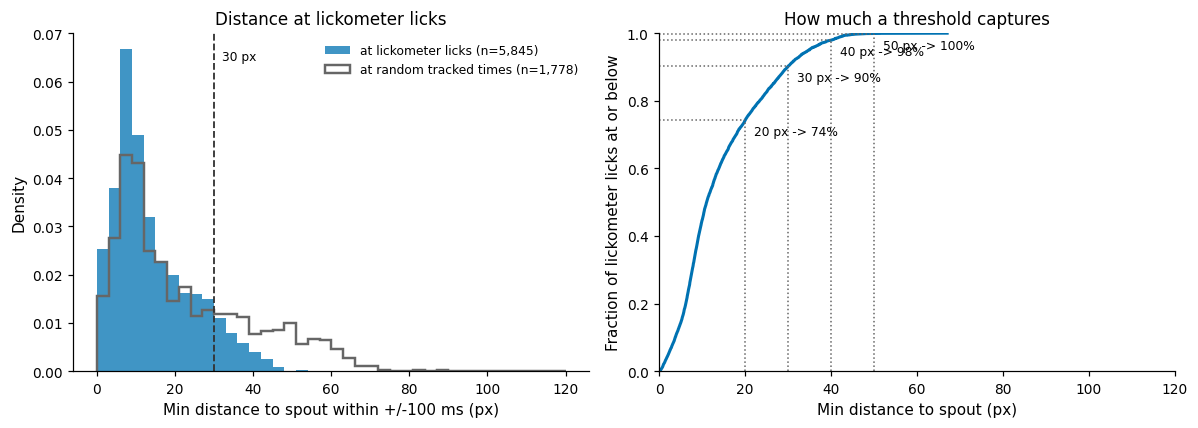

Distance at lickometer licks (px), confidence >= 0.8:
  10th 3.7 | 25th 7.0 | median 11.0 | 75th 20.4 | 90th 29.9

Windows with no tracked frame (dropped from the histogram):
  at lickometer licks:         1 / 5,846  (0.0%)
  at random times:         4,068 / 5,846  (69.6%)
  frames passing confidence >= 0.8: 12.4% of the session


In [29]:
if not IS_CO:
    print("[skip] Figure 2 needs the example session.")
else:
    # Confidence-filtered frames only: spout_distance is NaN wherever masking removed x/y.
    trk = tongue.loc[tongue["spout_distance"].notna(), ["time", "spout_distance"]]
    trk_t = trk["time"].to_numpy()
    trk_d = trk["spout_distance"].to_numpy()

    HALFWIDTH = 0.1
    d_at_lick = min_distance_near(trk_t, trk_d, all_licks, HALFWIDTH)

    # Same filtered arrays, so the null is conditioned on the tongue being tracked.
    rng = np.random.default_rng(0)
    random_times = rng.uniform(tongue["time"].min(), tongue["time"].max(), len(all_licks))
    d_at_random = min_distance_near(trk_t, trk_d, random_times, HALFWIDTH)

    no_track = np.isnan(d_at_lick)
    no_track_random = np.isnan(d_at_random)

    fig, axs = plt.subplots(1, 2, figsize=(11, 4))

    # Densities, not counts: the two samples have different n after dropping empty windows.
    bins = np.arange(0, 121, 3)
    axs[0].hist(d_at_lick[~no_track], bins=bins, density=True, color=C_LICKO, alpha=0.75,
                label="at lickometer licks (n={:,})".format(int((~no_track).sum())))
    axs[0].hist(d_at_random[~no_track_random], bins=bins, density=True, histtype="step", lw=1.6,
                color=PALETTE["neutral"],
                label="at random tracked times (n={:,})".format(int((~no_track_random).sum())))
    axs[0].axvline(PIXEL_THRESHOLD, color=PALETTE["all"], ls="--", lw=1.2)
    axs[0].text(PIXEL_THRESHOLD + 2, axs[0].get_ylim()[1] * 0.92,
                "{} px".format(PIXEL_THRESHOLD), fontsize=8)
    axs[0].set_xlabel("Min distance to spout within +/-{:.0f} ms (px)".format(HALFWIDTH * 1000))
    axs[0].set_ylabel("Density")
    axs[0].set_title("Distance at lickometer licks")
    axs[0].legend(fontsize=8)

    # CDF, with the candidate thresholds marked
    srt = np.sort(d_at_lick[~no_track])
    cdf = np.arange(1, srt.size + 1) / srt.size
    axs[1].plot(srt, cdf, lw=2, color=C_LICKO)
    for px in [20, 30, 40, 50]:
        frac = float((srt <= px).mean())
        axs[1].plot([px, px], [0, frac], color=PALETTE["neutral"], ls=":", lw=1)
        axs[1].plot([0, px], [frac, frac], color=PALETTE["neutral"], ls=":", lw=1)
        axs[1].annotate("{} px -> {:.0%}".format(px, frac), (px, frac),
                        textcoords="offset points", xytext=(6, -10), fontsize=8)
    axs[1].set_xlim(0, 120)
    axs[1].set_ylim(0, 1)
    axs[1].set_xlabel("Min distance to spout (px)")
    axs[1].set_ylabel("Fraction of lickometer licks at or below")
    axs[1].set_title("How much a threshold captures")

    for ax in axs:
        style_ax(ax)
    fig.tight_layout()
    save_fig(fig, "fig2_distance_at_licks", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    pct = np.nanpercentile(d_at_lick, [10, 25, 50, 75, 90])
    print("Distance at lickometer licks (px), confidence >= {}:".format(CONF))
    print("  10th {:.1f} | 25th {:.1f} | median {:.1f} | 75th {:.1f} | 90th {:.1f}".format(*pct))
    print("\nWindows with no tracked frame (dropped from the histogram):")
    print("  at lickometer licks:    {:>6,} / {:,}  ({:.1%})".format(
        int(no_track.sum()), no_track.size, no_track.mean()))
    print("  at random times:        {:>6,} / {:,}  ({:.1%})".format(
        int(no_track_random.sum()), no_track_random.size, no_track_random.mean()))
    print("  frames passing confidence >= {}: {:.1%} of the session".format(
        CONF, float(tongue["x"].notna().mean())))

### Reading the output

Distance at a confirmed lick: median 11.0 px, 90th percentile 29.9. The distribution is
concentrated below 30 px and saturates by 50. A 30 px threshold captures 90% of confirmed licks.

1 of 5,846 lick windows had no tracked frame, against 69.6% of random windows. Tracking is present
essentially whenever the lickometer fires, so untracked frames do not limit sensitivity here.

Median distance is 3x the `tongue_tip_center` error of 3.67 px (`pixel_error.ipynb`), so part of
the observed spread is measurement noise.

## 5. Threshold sweep

Each threshold classifies every event into the three categories, giving a pose-only count and a
precision — of the licks the pose detector calls, the fraction the lickometer also registered.

In [30]:
def classify_events(tongue, licks, spoutL, spoutR, threshold,
                    t_refractory=None, match_window=None):
    """Detect pose licks at one threshold and classify against the lickometer.

    Returns
    -------
    dict
        Counts (``n_matched``, ``n_pose_only``, ``n_lickometer_only``), the derived
        fractions, and the pose-only / lickometer-only event times.
    """
    t_refractory = T_REFRACTORY if t_refractory is None else t_refractory
    match_window = MATCH_WINDOW if match_window is None else match_window

    pose_licks = detect_licks(tongue, spoutL, spoutR, threshold)
    pose_licks = filter_timestamps_refractory(pose_licks, t_refractory)
    licko_licks = filter_timestamps_refractory(list(licks), t_refractory)

    # Pose events are passed first, so the second count is unmatched lickometer events
    # and the third is unmatched pose events (see val_02 for the argument order).
    n_matched, n_lickometer_only, n_pose_only, pose_tbl, licko_tbl = (
        calculate_metrics_witheventkeys(pose_licks, licko_licks, time_window=match_window))

    n_pose = n_matched + n_pose_only
    n_licko = n_matched + n_lickometer_only
    return {
        "threshold": threshold,
        "n_matched": n_matched,
        "n_pose_only": n_pose_only,
        "n_lickometer_only": n_lickometer_only,
        "n_pose": n_pose,
        "n_lickometer": n_licko,
        # Precision: of the licks pose calls, the fraction the lickometer confirms.
        "precision": n_matched / n_pose if n_pose > 0 else np.nan,
        # Recall: of the lickometer's licks, the fraction pose also finds.
        "recall": n_matched / n_licko if n_licko > 0 else np.nan,
        "pose_only_times": pose_tbl.loc[
            pose_tbl["Status"] == "False Negative", "Time"].to_numpy(),
        "lickometer_only_times": licko_tbl.loc[
            licko_tbl["Status"] == "False Positive", "Time"].to_numpy(),
    }

In [31]:
if not IS_CO:
    print("[skip] Figure 3 needs the example session.")
else:
    sweep_thresholds = np.arange(10, 61, 5)
    sweep = [classify_events(tongue, all_licks, S["spoutL"], S["spoutR"], px)
             for px in sweep_thresholds]
    sweep_df = pd.DataFrame([{k: v for k, v in r.items() if not k.endswith("_times")}
                             for r in sweep])
    sweep_df["pose_only_per_min"] = sweep_df["n_pose_only"] / (duration / 60.0)
    display(sweep_df[["threshold", "n_matched", "n_pose_only", "n_lickometer_only",
                      "precision", "recall", "pose_only_per_min"]].round(3))

Filtered 587 events!
Filtered 4 events!
Filtered 853 events!
Filtered 4 events!
Filtered 951 events!
Filtered 4 events!
Filtered 1086 events!
Filtered 4 events!
Filtered 1141 events!
Filtered 4 events!
Filtered 1206 events!
Filtered 4 events!
Filtered 1191 events!
Filtered 4 events!
Filtered 1047 events!
Filtered 4 events!
Filtered 921 events!
Filtered 4 events!
Filtered 639 events!
Filtered 4 events!
Filtered 577 events!
Filtered 4 events!


,threshold,n_matched,n_pose_only,n_lickometer_only,precision,recall,pose_only_per_min
0,10,2617,24,3225,0.991,0.448,0.268
1,15,3693,58,2149,0.985,0.632,0.647
2,20,4333,95,1509,0.979,0.742,1.060
3,25,4819,125,1023,0.975,0.825,1.394
4,30,5263,198,579,0.964,0.901,2.208
5,35,5499,325,343,0.944,0.941,3.625
6,40,5523,520,319,0.914,0.945,5.800
7,45,5300,732,542,0.879,0.907,8.164
8,50,4590,963,1252,0.827,0.786,10.741
9,55,3420,933,2422,0.786,0.585,10.406


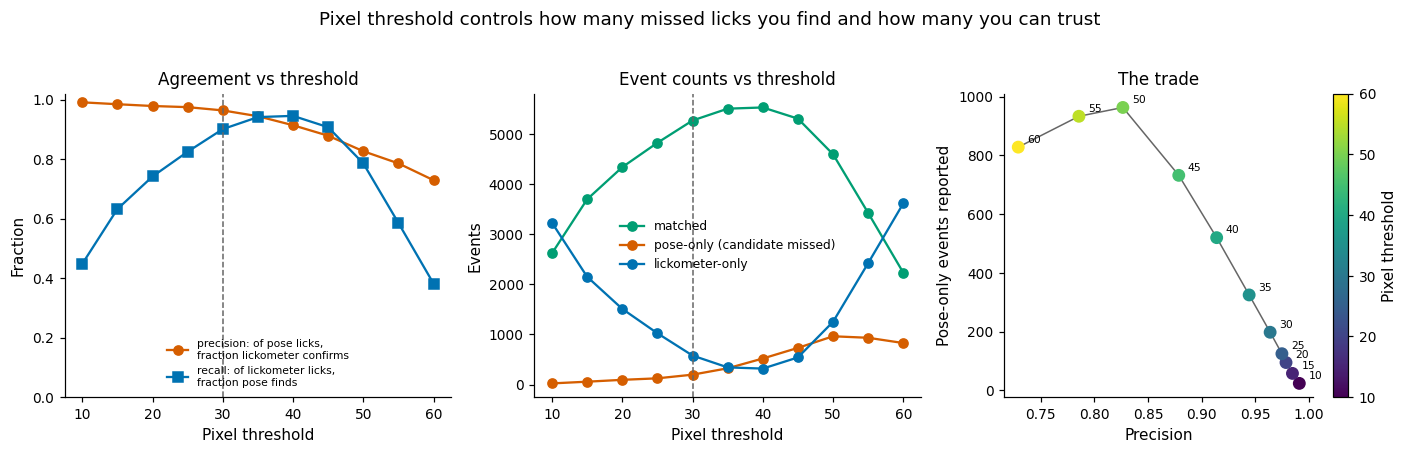

In [32]:
if not IS_CO:
    print("[skip] Figure 3 needs the example session.")
else:
    fig, axs = plt.subplots(1, 3, figsize=(13, 4))

    # -- panel 1: precision and recall --
    axs[0].plot(sweep_df["threshold"], sweep_df["precision"], "o-", color=C_POSE,
                label="precision: of pose licks,\nfraction lickometer confirms")
    axs[0].plot(sweep_df["threshold"], sweep_df["recall"], "s-", color=C_LICKO,
                label="recall: of lickometer licks,\nfraction pose finds")
    axs[0].axvline(PIXEL_THRESHOLD, color=PALETTE["neutral"], ls="--", lw=1)
    axs[0].set_ylim(0, 1.02)
    axs[0].set_xlabel("Pixel threshold")
    axs[0].set_ylabel("Fraction")
    axs[0].set_title("Agreement vs threshold")
    axs[0].legend(fontsize=7, loc="lower center")

    # -- panel 2: the three counts --
    axs[1].plot(sweep_df["threshold"], sweep_df["n_matched"], "o-", color=C_MATCH,
                label="matched")
    axs[1].plot(sweep_df["threshold"], sweep_df["n_pose_only"], "o-", color=C_POSE,
                label="pose-only (candidate missed)")
    axs[1].plot(sweep_df["threshold"], sweep_df["n_lickometer_only"], "o-", color=C_LICKO,
                label="lickometer-only")
    axs[1].axvline(PIXEL_THRESHOLD, color=PALETTE["neutral"], ls="--", lw=1)
    axs[1].set_xlabel("Pixel threshold")
    axs[1].set_ylabel("Events")
    axs[1].set_title("Event counts vs threshold")
    axs[1].legend(fontsize=8)

    # -- panel 3: the trade, as a curve --
    axs[2].plot(sweep_df["precision"], sweep_df["n_pose_only"], "-", color=PALETTE["neutral"],
                lw=1, zorder=1)
    sc = axs[2].scatter(sweep_df["precision"], sweep_df["n_pose_only"],
                        c=sweep_df["threshold"], cmap="viridis", s=55, zorder=2)
    for _, r in sweep_df.iterrows():
        axs[2].annotate("{:.0f}".format(r["threshold"]), (r["precision"], r["n_pose_only"]),
                        textcoords="offset points", xytext=(6, 3), fontsize=7)
    fig.colorbar(sc, ax=axs[2], label="Pixel threshold")
    axs[2].set_xlabel("Precision")
    axs[2].set_ylabel("Pose-only events reported")
    axs[2].set_title("The trade")

    for ax in axs:
        style_ax(ax)
    fig.suptitle("Pixel threshold controls how many missed licks you find "
                 "and how many you can trust", y=1.02)
    fig.tight_layout()
    save_fig(fig, "fig3_threshold_tradeoff", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

### Reading the output

Raising the threshold admits more excursions: more candidates, lower precision, since the extra
detections include approaches that never contacted.

Precision stays above 0.95 out to 35 px while recall climbs from 0.45 to 0.94; the curves cross
near 35 px. At 30 px, precision 0.964 and recall 0.901.

The third panel is the operating point. Each marker is one threshold: right is more trustworthy
events, up is more of them.

Pose-only counts never reach zero at any threshold. §6 looks at what those events are.

## 6. Individual pose-only events

Trajectory panels: tongue x, y and distance to spout around each event. A lick reaches the spout
and dwells; a detector error grazes the threshold or jumps discontinuously.

Video clips: the labeled video cut around each event.

Clip times convert from session time through `session_time_to_video_time` with the §2 offset.
`find_labeled_video` locates the session's labeled video under the data root.

In [33]:
def plot_event_panels(tongue, event_times, event_label, clip_length=1.0, n_max=4,
                      threshold=None):
    """Tongue x, y and spout distance around each of up to n_max events."""
    threshold = PIXEL_THRESHOLD if threshold is None else threshold
    event_times = np.asarray(event_times, dtype=float)[:n_max]
    if event_times.size == 0:
        print("No events to plot.")
        return

    fig, axs = plt.subplots(3, event_times.size, figsize=(3.1 * event_times.size, 6),
                            sharex="col", squeeze=False)
    for j, t0 in enumerate(event_times):
        win = tongue[(tongue["time"] >= t0 - clip_length / 2) &
                     (tongue["time"] <= t0 + clip_length / 2)]
        for row, (col, label) in enumerate([("y", "Y (px)"), ("x", "X (px)"),
                                            ("spout_distance", "Dist. to spout (px)")]):
            ax = axs[row][j]
            ax.plot(win["time"], win[col], ".-", ms=2, lw=1,
                    color=PALETTE["all"] if row < 2 else C_POSE)
            ax.axvline(t0, color=PALETTE["neutral"], ls="--", lw=1)
            if row == 2:
                ax.axhline(threshold, color=PALETTE["neutral"], ls=":", lw=1)
                ax.set_ylim(0, 120)
                ax.set_xlabel("Time in session (s)")
            if j == 0:
                ax.set_ylabel(label)
            style_ax(ax)
        axs[0][j].set_title("{:.2f} s".format(t0), fontsize=9)

    fig.suptitle("{} (dashed = event, dotted = {} px threshold)".format(event_label, threshold),
                 y=1.01)
    fig.tight_layout()
    return fig

Filtered 1141 events!
Filtered 4 events!
At 30 px / 0.1 s refractory / 0.1 s match window:
  matched:          5,263
  pose-only:        198   <- candidate missed licks
  lickometer-only:  579
  precision:        0.964
  recall:           0.901


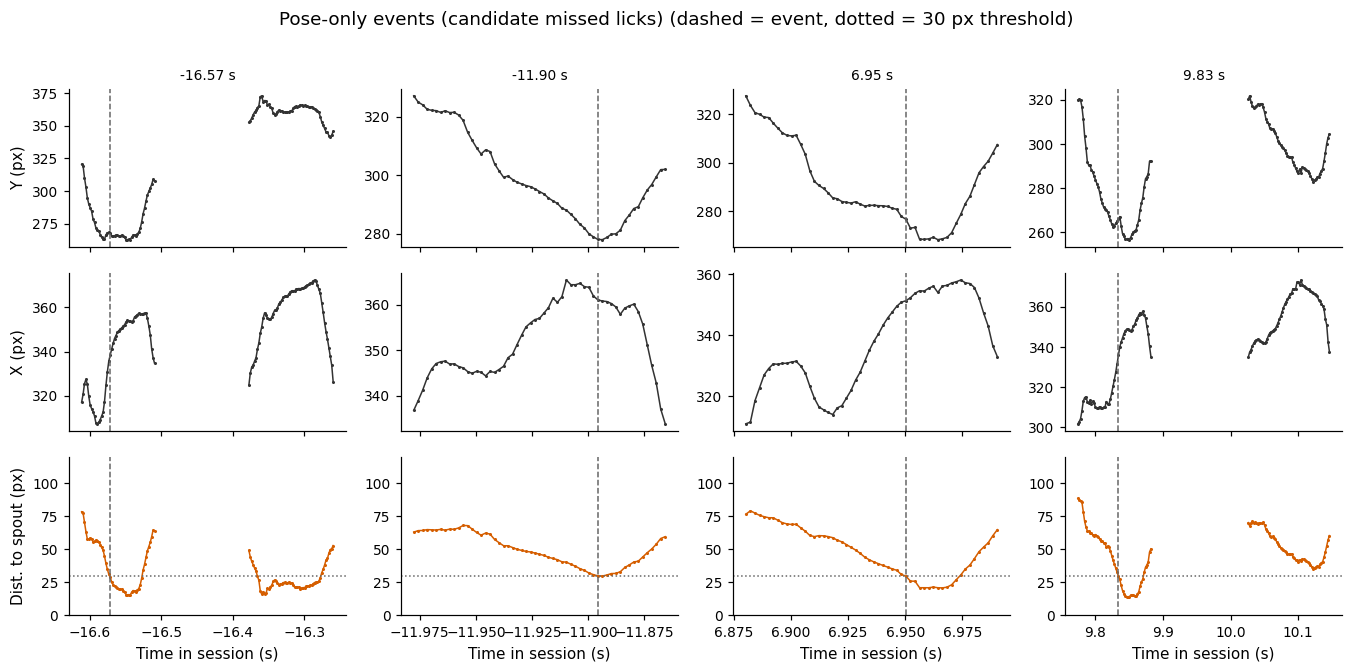

In [34]:
if not IS_CO:
    print("[skip] Event panels need the example session.")
else:
    ref = classify_events(tongue, all_licks, S["spoutL"], S["spoutR"], PIXEL_THRESHOLD)
    pose_only_times = ref["pose_only_times"]
    lickometer_only_times = ref["lickometer_only_times"]

    print("At {} px / {} s refractory / {} s match window:".format(
        PIXEL_THRESHOLD, T_REFRACTORY, MATCH_WINDOW))
    print("  matched:          {:,}".format(ref["n_matched"]))
    print("  pose-only:        {:,}   <- candidate missed licks".format(ref["n_pose_only"]))
    print("  lickometer-only:  {:,}".format(ref["n_lickometer_only"]))
    print("  precision:        {:.3f}".format(ref["precision"]))
    print("  recall:           {:.3f}".format(ref["recall"]))

    fig = plot_event_panels(tongue, pose_only_times, "Pose-only events (candidate missed licks)")
    if fig is not None:
        save_fig(fig, "fig4_pose_only_panels", fig_dir=FIG_DIR, save=SAVE_FIG)
        plt.show()

Filtered 1141 events!


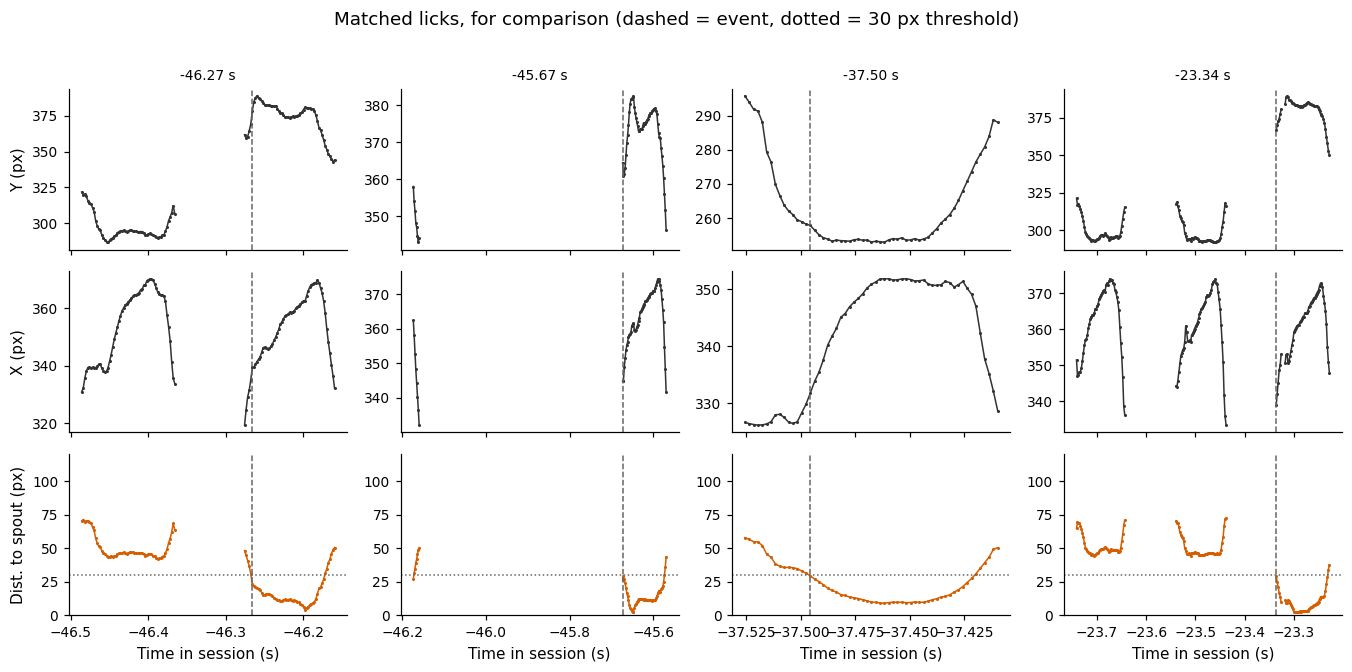

In [35]:
if not IS_CO:
    print("[skip] Comparison panels need the example session.")
else:
    # Matched licks, for contrast: this is what a confirmed lick looks like.
    pose_all = detect_licks(tongue, S["spoutL"], S["spoutR"], PIXEL_THRESHOLD)
    pose_all = np.asarray(filter_timestamps_refractory(pose_all, T_REFRACTORY))
    matched_times = np.setdiff1d(pose_all, pose_only_times)

    fig = plot_event_panels(tongue, matched_times, "Matched licks, for comparison")
    if fig is not None:
        save_fig(fig, "fig5_matched_panels", fig_dir=FIG_DIR, save=SAVE_FIG)
        plt.show()

In [ ]:
if not IS_CO:
    print("[skip] Clip extraction needs the example session and the labeled video.")
else:
    CLIP_LENGTH = 1.0
    N_CLIPS = 5

    try:
        labeled_video = find_labeled_video(EXAMPLE_SESSION, DATA)
    except FileNotFoundError as exc:
        labeled_video = None
        print("[skip] {}".format(exc))
        print("       find_labeled_video looks for"
              " <data_root>/<session>*/pred_outputs/video_preds/labeled_videos/*_labeled.mp4")

    if labeled_video is not None:
        print("Labeled video: {}".format(labeled_video))
        for times, name in [(pose_only_times, "pose_only"),
                            (lickometer_only_times, "lickometer_only")]:
            if len(times) == 0:
                print("{}: no events".format(name))
                continue
            # Session time -> video time, then back up half a clip to center the event.
            starts = (session_time_to_video_time(
                np.asarray(times[:N_CLIPS], dtype=float), VIDEO_OFFSET) - CLIP_LENGTH / 2)
            out_dir = SCRATCH / "labeled_clips" / "val_03" / name
            print("{}: {} clips -> {}".format(name, len(starts), out_dir))
            # extract_clips_ffmpeg_encode re-encodes, so the cut lands on the requested frame.
            # video_clip_utils.extract_clips_ffmpeg_after_reencode is faster but stream-copies,
            # which snaps the start to the nearest preceding keyframe -- too coarse for a 1 s
            # clip centered on a single event.
            extract_clips_ffmpeg_encode(str(labeled_video), starts, CLIP_LENGTH, str(out_dir))

### Reading the output

Compare the pose-only panels against the matched panels. Traces that dip well below the threshold
and dwell there are licks the lickometer did not register. Traces that graze it, or jump
discontinuously, are the detector firing on something else.

The clips decide it. Nothing here settles a single event on its own.

## 7. Miss rate per session

`precision(d)` = P(lickometer fires | tongue reached within `d`), per session, at
d = 10, 15, 20, 25, 30, 40 px. Sessions are ranked by the miss rate at 10 px, with Wilson 95%
intervals. Sessions with fewer than `MIN_N_POSE` qualifying events are reported but not ranked;
`n_pose` spans 145 to 3928 across the set, so the small ones carry intervals 10-15 points wide.

10 px is 2.7x the `tongue_tip_center` error of 3.67 px (`pixel_error.ipynb`). Tighter measures
keypoint noise.

`lick_coverage` — of the lickometer's licks, the fraction with a tracked tongue within ±100 ms —
replaces `tracked_frac` as the pose-quality covariate. `tracked_frac` counts every tongue-visible
frame, so it rises with non-lick tongue movement as well as with tracking quality, and correlates
with the miss rate for both reasons (+0.329 at 30 px, +0.277 at 10 px). `lick_coverage` conditions
on a lick having happened, which divides the behaviour out.

In [ ]:
DIAG_THRESHOLDS = [10, 15, 20, 25, 30, 40]
D0 = 10          # px; 2.7x the tongue_tip_center error of 3.67 px (pixel_error.ipynb)
MIN_N_POSE = 300 # sessions with fewer qualifying events at D0 are reported, not ranked


def wilson_ci(k, n, z=1.96):
    """Wilson score interval for k successes in n trials."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return centre - half, centre + half


def session_precision_curve(sdir, thresholds=None):
    """precision(d) for one session. Loads once, sweeps d. None if unusable."""
    thresholds = DIAG_THRESHOLDS if thresholds is None else thresholds
    inter = Path(sdir) / "intermediate_data"
    needed = ["kps_raw_tongue_tip_center.parquet", "kps_raw_spout_l.parquet",
              "kps_raw_spout_r.parquet", "tongue_kins.parquet", "nwb_df_licks.parquet"]
    if not all((inter / f).exists() for f in needed):
        return None

    sess = load_session(inter)
    sess["tongue"] = add_spout_distance(sess["tongue"], sess["spoutL"], sess["spoutR"])
    tg = sess["tongue"]
    dur = float(tg["time"].max() - tg["time"].min())
    if dur <= 0 or len(sess["licks"]) == 0:
        return None

    # Pose sensitivity given a known lick: of the lickometer's licks, the fraction with a
    # tracked tongue nearby. Conditions on the lick, so it is independent of how much the
    # animal licked -- unlike tracked_frac, which counts every tongue-visible frame.
    trk = tg.loc[tg["spout_distance"].notna(), ["time", "spout_distance"]]
    d_at_lick = min_distance_near(trk["time"].to_numpy(), trk["spout_distance"].to_numpy(),
                                  sess["licks"], 0.1)
    lick_coverage = float(np.mean(~np.isnan(d_at_lick)))

    out = []
    for d in thresholds:
        r = classify_events(tg, sess["licks"], sess["spoutL"], sess["spoutR"], d)
        lo, hi = wilson_ci(r["n_pose_only"], r["n_pose"])
        out.append({"session": Path(sdir).name, "d": d,
                    "duration_s": dur, "tracked_frac": float(tg["x"].notna().mean()),
                    "lick_coverage": lick_coverage,
                    "n_pose": r["n_pose"], "n_matched": r["n_matched"],
                    "n_pose_only": r["n_pose_only"],
                    "precision": r["precision"], "recall": r["recall"],
                    "miss_rate": 1 - r["precision"], "miss_lo": lo, "miss_hi": hi,
                    "misses_per_min": r["n_pose_only"] / (dur / 60.0)})
    return pd.DataFrame(out)

In [ ]:
MAX_SESSIONS = None   # set to an int to cut the loop short while iterating

if not IS_CO:
    print("[skip] Needs session_analysis_mlk/*/intermediate_data/.")
else:
    import contextlib, io

    session_dirs = sorted(glob.glob(str(SESSION_DIR / "*")))
    if MAX_SESSIONS is not None:
        session_dirs = session_dirs[:MAX_SESSIONS]

    frames = []
    for k, sdir in enumerate(session_dirs, 1):
        try:
            # filter_timestamps_refractory prints once per call; muted to keep the log readable.
            with contextlib.redirect_stdout(io.StringIO()):
                curve = session_precision_curve(sdir)
        except Exception as exc:
            print("  [{}/{}] {}: FAILED ({})".format(k, len(session_dirs), Path(sdir).name, exc))
            continue
        if curve is None:
            continue
        frames.append(curve)
        a = curve[curve["d"] == D0].iloc[0]
        print("  [{}/{}] {}  miss {:.2%} [{:.1%},{:.1%}]  n={}  coverage {:.1%}".format(
            k, len(session_dirs), a["session"], a["miss_rate"], a["miss_lo"], a["miss_hi"],
            int(a["n_pose"]), a["lick_coverage"]))

    curves_df = pd.concat(frames, ignore_index=True)

    triage = curves_df[curves_df["d"] == D0].copy()
    triage["subject"] = triage["session"].str.split("_").str[1]
    triage["rankable"] = triage["n_pose"] >= MIN_N_POSE
    # Day-to-day swing within an animal. Hardware faults are intermittent; behaviour is not.
    spread = (triage[triage["rankable"]].groupby("subject")["miss_rate"]
              .agg(["min", "max", "size"]))
    spread["subject_spread"] = spread["max"] - spread["min"]
    triage = triage.merge(spread[["subject_spread", "size"]].rename(
        columns={"size": "n_sessions"}), left_on="subject", right_index=True, how="left")
    triage = triage.sort_values(["rankable", "miss_rate"], ascending=[False, False]).reset_index(drop=True)

    print("\nSessions {}   rankable (n>={}) {}   miss median {:.2%}".format(
        len(triage), MIN_N_POSE, int(triage["rankable"].sum()),
        triage.loc[triage["rankable"], "miss_rate"].median()))

In [ ]:
if not IS_CO or len(curves_df) == 0:
    print("[skip] Needs the sweep above.")
else:
    rankable = triage[triage["rankable"]]
    flagged = rankable.head(5)["session"].tolist()

    fig, axs = plt.subplots(1, 2, figsize=(12, 5.2), layout="constrained")

    # -- panel 1: precision(d), one line per session --
    for sess, g in curves_df.groupby("session"):
        g = g.sort_values("d")
        hot = sess in flagged
        axs[0].plot(g["d"], g["precision"], "-o" if hot else "-",
                    color=C_POSE if hot else PALETTE["not_sig"],
                    lw=2 if hot else 1, ms=4, alpha=1.0 if hot else 0.4,
                    zorder=3 if hot else 1,
                    label="{} {}".format(sess.split("_")[1], sess.split("_")[2]) if hot else None)
    axs[0].axvline(D0, color=PALETTE["all"], ls="--", lw=1)
    axs[0].annotate("D0", xy=(D0, 1.0), xycoords=("data", "axes fraction"),
                    xytext=(3, -11), textcoords="offset points", fontsize=8,
                    color=PALETTE["all"])
    axs[0].set_ylim(max(0.0, float(curves_df["precision"].min()) - 0.03), 1.005)
    axs[0].set_xlabel("Distance to spout, d (px)")
    axs[0].set_ylabel("P(lickometer fires | tongue within d)")
    axs[0].set_title("precision(d), all sessions")
    axs[0].legend(fontsize=7, loc="lower right", framealpha=0.9)

    # -- panel 2: ranking with Wilson CIs --
    y = np.arange(len(triage))
    for lbl, mask, col in [("n >= {}".format(MIN_N_POSE), triage["rankable"], C_POSE),
                           ("n < {} (not ranked)".format(MIN_N_POSE), ~triage["rankable"],
                            PALETTE["not_sig"])]:
        sub = triage[mask]
        if not len(sub):
            continue
        axs[1].errorbar(sub["miss_rate"], y[mask.to_numpy()],
                        xerr=[sub["miss_rate"] - sub["miss_lo"],
                              sub["miss_hi"] - sub["miss_rate"]],
                        fmt="o", ms=4, lw=1, color=col, ecolor=col, alpha=0.85, label=lbl)
    axs[1].axvline(rankable["miss_rate"].median(), color=PALETTE["all"], ls="--", lw=1,
                   label="median {:.1%}".format(rankable["miss_rate"].median()))
    axs[1].invert_yaxis()
    axs[1].set_yticks([])
    axs[1].set_xlabel("Miss rate at {} px (95% Wilson CI)".format(D0))
    axs[1].set_ylabel("Session (ranked)")
    axs[1].set_title("Review queue")
    axs[1].legend(fontsize=7, loc="lower right")

    for ax in axs:
        style_ax(ax)
    save_fig(fig, "fig6_precision_curves", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    cols = ["session", "miss_rate", "miss_lo", "miss_hi", "n_pose",
            "lick_coverage", "tracked_frac", "subject_spread"]
    print("Review queue, top 10 of the rankable sessions:")
    display(rankable[cols].head(10).round(4))

    print("Day-to-day swing within an animal, largest first:")
    display(rankable.groupby("subject")
            .agg(n_sessions=("miss_rate", "size"), lo=("miss_rate", "min"),
                 hi=("miss_rate", "max"), spread=("subject_spread", "first"))
            .query("n_sessions >= 2").sort_values("spread", ascending=False).round(4))

    print("Pose-quality covariates vs miss_rate:")
    for col in ["lick_coverage", "tracked_frac"]:
        v = rankable[col]
        # A covariate with no spread has no defined rank correlation. That is a result:
        # it means the quantity is uniform across sessions, not that the check failed.
        rho = v.corr(rankable["miss_rate"], method="spearman") if v.nunique() > 2 else np.nan
        print("  {:<14} range {:.3f}-{:.3f}   spearman {}".format(
            col, v.min(), v.max(),
            "n/a (no spread)" if not np.isfinite(rho) else "{:+.3f}".format(rho)))
    print("  tracked_frac was +0.329 at 30 px and +0.277 at {} px.".format(D0))
    print("  lick_coverage near 1 in every session means pose saw the tongue whenever the")
    print("  lickometer fired, so the tracked_frac correlation is not pose sensitivity.")

### Reading the output

Each curve rises toward 1 as `d` tightens. A curve that stays low at small `d` means the
lickometer failed on licks the tongue completed.

Panel 2 ranks sessions by miss rate at 10 px. Intervals that overlap the median are not evidence
of anything.

`spearman(miss_rate, lick_coverage)` is the pose-sensitivity check; `tracked_frac` is printed
beside it for comparison.

Day-to-day swing within an animal is the second table. Behaviour does not move fast; intermittent
hardware does, so a large within-subject spread is a stronger flag than a high rank.

If the lickometer fails on glancing contacts, those licks sit at larger `d` and are excluded at
10 px, so the miss rate is biased low. A tongue that passes near a spout without contacting can
still fall within 10 px, which biases it high. Video settles both.

Previous version of this section, fixed 30 px over 53 sessions: git tag
`val_03-fixed-30px-baseline`.

## 8. Possible QC metrics

### A. Session-level miss rate
`miss_rate` at 10 px with its Wilson interval (§7). One number per session, no trial alignment.
Still correlates with `tracked_frac` at +0.277, so it is not cleanly separated from how much the
animal licked.

### B. Per-trial flag
Trials where a pose lick falls in the response window and the lickometer records none. Sensitive
to the window bounds, and carries the pose false-positive rate from §5.

### C. High-confidence event list
The event-level counterpart of A: pose-only events whose minimum distance falls below a percentile
of the distance at confirmed licks (§4). `CONFIDENT_PCTL = 25` put the cut at 7.0 px on the
example session — tighter than `D0` — and reduced 198 pose-only events to 6. Raise the percentile
for a longer review list.

### D. Coverage gate
Two numbers from §7 decide whether A-C can be reported for a session at all.

- `lick_coverage` — of the lickometer's licks, the fraction with a tracked tongue within ±100 ms.
  Low coverage means pose did not see the licks, so pose-only counts are not interpretable.
- `n_pose` at 10 px — qualifying events. Below `MIN_N_POSE` the Wilson interval is wider than the
  spread between sessions.

Neither measures missed licks.

### E. Within-subject spread
Day-to-day range of A within one animal (§7). `791691` ran 1.8-38.2% across four consecutive days;
`782394` ran 0.0-1.6%. Behaviour does not move that fast, so a large spread points at intermittent
hardware. Needs several sessions per animal.

In [ ]:
RESPONSE_WINDOW = (0.0, 2.0)   # s after go cue; matches the cue-response window used elsewhere
CONFIDENT_PCTL  = 25           # percentile of confirmed-lick distance for metric C

if not IS_CO:
    print("[skip] Metric demonstration needs the example session.")
else:
    # --- C: high-confidence pose-only events ---
    d_pose_only = min_distance_near(trk_t, trk_d, pose_only_times, 0.05)
    cutoff = float(np.nanpercentile(d_at_lick, CONFIDENT_PCTL))
    confident = pose_only_times[np.nan_to_num(d_pose_only, nan=np.inf) <= cutoff]
    print("C. high-confidence event list")
    print("   cutoff = {}th pctl of distance at confirmed licks = {:.1f} px  (D0 = {} px)".format(
        CONFIDENT_PCTL, cutoff, D0))
    print("   pose-only events: {:,} -> high-confidence: {:,} ({:.0%})".format(
        len(pose_only_times), len(confident),
        len(confident) / max(len(pose_only_times), 1)))

    # --- B: per-trial flag ---
    trials_path = inter / "nwb_df_trials.parquet"
    if not trials_path.exists():
        print("\nB. [skip] nwb_df_trials.parquet not found")
    else:
        trials = pd.read_parquet(trials_path)
        cue_col = "goCue_start_time_in_session"
        if cue_col not in trials.columns:
            print("\nB. [skip] {} not in nwb_df_trials ({})".format(
                cue_col, list(trials.columns)[:6]))
        else:
            cues = trials[cue_col].dropna().to_numpy()
            def _n_in_window(times, cue):
                t = np.asarray(times, dtype=float)
                return int(((t >= cue + RESPONSE_WINDOW[0]) &
                            (t <= cue + RESPONSE_WINDOW[1])).sum())
            flag = pd.DataFrame({
                "trial": np.arange(len(cues)),
                "go_cue": cues,
                "n_lickometer": [_n_in_window(all_licks, c) for c in cues],
                "n_pose_only": [_n_in_window(pose_only_times, c) for c in cues],
                "n_confident": [_n_in_window(confident, c) for c in cues],
            })
            flagged = flag[(flag["n_lickometer"] == 0) & (flag["n_pose_only"] > 0)]
            flagged_hc = flag[(flag["n_lickometer"] == 0) & (flag["n_confident"] > 0)]
            print("\nB. per-trial flag, response window {}-{} s".format(*RESPONSE_WINDOW))
            print("   trials: {:,}".format(len(flag)))
            print("   no lickometer lick but a pose lick: {:,} ({:.1%} of trials)".format(
                len(flagged), len(flagged) / max(len(flag), 1)))
            print("   same, high-confidence only:         {:,} ({:.1%} of trials)".format(
                len(flagged_hc), len(flagged_hc) / max(len(flag), 1)))
            display(flagged.head(10))

## 9. Limitations

1. A pose-only event is a candidate. Separating a lickometer failure from a pose error needs the
   video; the §7 miss rate carries the pose false-positive rate as its error term.
2. If the lickometer fails on glancing contacts, those licks sit at larger `d` and are excluded at
   10 px, biasing the miss rate low.
3. Pixel distances are not comparable across sessions. Euclidean jaw-to-endpoint at licking
   movements spans 53-95 px across the set, a factor of 1.8. Conditioning on a tight `d` limits
   the effect but does not remove it.
4. `behavior_856239_2026-07-24` has no pose output, so #96's own session is not reproduced. The
   rates come from 53 sessions, 2024-05-31 to 2025-07-03.
5. Detection rests on `tongue_tip_center` from one camera against session-mean spout positions. A
   spout that moves mid-session biases the distance trace for part of the session.
6. Precision is measured against the lickometer, the instrument under test. An accuracy estimate
   needs events scored by eye from video. §6 extracts the clips; the scoring is not done.

## 10. Export

Writes the numbers behind every figure to `FIG_DIR/val_03_summary.json`. Set `SAVE_FIG = True` in
§1 to also write the figure PNGs.

In [ ]:
if not IS_CO:
    print("[skip] Export needs the analysis above.")
else:
    import json as _json

    def _grab(name):
        """Return a global if the cell that defines it ran, else None."""
        return globals().get(name)

    summary = {
        "session": EXAMPLE_SESSION,
        "params": {"pixel_threshold": PIXEL_THRESHOLD, "t_refractory": T_REFRACTORY,
                   "match_window": MATCH_WINDOW, "confidence": CONF},
        "example": {"duration_s": duration, "n_frames": int(len(tongue)),
                    "tracked_frac": float(tongue["x"].notna().mean()),
                    "n_lickometer": int(len(all_licks)),
                    "video_offset_s": VIDEO_OFFSET},
        "distance_at_licks_pctl": {
            str(q): float(np.nanpercentile(d_at_lick, q)) for q in [10, 25, 50, 75, 90]},
        "licks_without_tracking_frac": float(np.isnan(d_at_lick).mean()),
        "at_operating_point": {k: (float(ref[k]) if isinstance(ref[k], float) else int(ref[k]))
                               for k in ["n_matched", "n_pose_only", "n_lickometer_only",
                                         "precision", "recall"]},
    }

    sw = _grab("sweep_df")
    if sw is not None:
        summary["threshold_sweep"] = sw.drop(columns=[c for c in sw.columns
                                                      if c.endswith("_times")]).to_dict("records")
    tr = _grab("triage")
    if tr is not None and len(tr):
        summary["triage"] = tr.to_dict("records")
        summary["across_sessions"] = {
            "n": int(len(tr)), "D0": D0,
            "miss_rate_median": float(tr["miss_rate"].median()),
            "miss_rate_min": float(tr["miss_rate"].min()),
            "miss_rate_max": float(tr["miss_rate"].max()),
            "tracked_frac_median": float(tr["tracked_frac"].median()),
            "spearman_miss_vs_tracked": float(
                tr["miss_rate"].corr(tr["tracked_frac"], method="spearman")),
        }
    cv = _grab("curves_df")
    if cv is not None and len(cv):
        summary["precision_curves"] = cv.to_dict("records")
    cf = _grab("confident")
    if cf is not None:
        summary["metric_c"] = {"percentile": CONFIDENT_PCTL, "cutoff_px": float(cutoff),
                               "n_pose_only": int(len(pose_only_times)),
                               "n_confident": int(len(cf))}
    fl = _grab("flagged")
    if fl is not None:
        summary["metric_b"] = {"response_window": list(RESPONSE_WINDOW),
                               "n_trials": int(len(_grab("flag"))),
                               "n_flagged": int(len(fl)),
                               "n_flagged_high_conf": int(len(_grab("flagged_hc")))}

    FIG_DIR.mkdir(parents=True, exist_ok=True)
    out = FIG_DIR / "val_03_summary.json"
    out.write_text(_json.dumps(summary, indent=2, default=float))
    print("wrote {}".format(out))
    print("sections captured: {}".format(", ".join(sorted(summary))))
    if not SAVE_FIG:
        print("\nSAVE_FIG is False - set it True in S1 and re-run to write the figure PNGs.")